# Data Driven Models: Logistic Regression

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix
from sklearn.preprocessing import StandardScaler

print("packages imported")

packages imported


## Bankruptcy Data

The file `bankruptcy.csv` comes from the [UC Irvine Machine Learing Repository](https://archive.ics.uci.edu/dataset/572/taiwanese+bankruptcy+prediction) and contains a dataset with 6819 samples and 95 features describing financial properties of companies on the Taiwan Stock Exchange. The target value is whether or not the company went bankrupt (with $y=1$ if true and $y=0$ if false).

Construct a mathematical model to predict whether a company went bankrupt or not. 

**Problem Statement:**

Based on the features of the company, predict using logistic regression whether they will go bankrupt or not.

**Variables and parameters:**
- We have $95$ features (independent variables) for this dataset, which is too many to list out. Some examples of the features are:
    -  Operating Profit Rate
    -  Cash Flow Rate
    -  Tax Rate (A)
    -  Cash Reinvestment %
- We have a target variable (dependent variable) of bankrupty.
- Regularization parameter, $\alpha$
- Vector of logistic regression parameters, $\bf{W}$
- Bias ${b}$

**Assumptions and Constraints:**
- only consider the $95$ features in the dataset (i.e., there are no external factors)
- the data is appropriate for logistic regression since the target has a binary output.
- trends in historical data will continue and there is no sudden changes (e.g., stock market doesn't crash)

**Build Solutions:**

Here, we will follow some pre-assigned tasks for the data. 

### Import Data

In [2]:
data = pd.read_csv('bankruptcy.csv')

In [3]:
data.shape

(6819, 96)

The targets are stored in the first column. Select the data matrix `X` and target vector `y`.

In [4]:
X = data.iloc[:,1:].values
y = data.iloc[:,0].values

### Feature Scaling and Regularization to Improve Convergence

What happens if we try to fit a logistic regression model using all the features with regularization parameter $C=1$?

In [5]:
model = LogisticRegression().fit(X,y)

/Users/lindseydaniels/anaconda3/lib/python3.11/site-packages/sklearn/linear_model/_logistic.py:460: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


The code above should give an error which says that the maximum number of iterations has been reached. Recall, the weight vector $\mathbf{W}$ and bias parameter $b$ are computed by minimizing the cost function and the minimization (ie. optimization) process is computed by a numerical method (such as gradient descent) which repeats a set of computations to move closer to an optimal value. But this example seems to require too many iterations of the numerical method. So what do we do?

We can increase the maximum number of iterations or we can try to find ways to help the numerical method converge more easily. Let's just try the first option. The default number of maximum iterations is `max_iter = 100` and so let's increase it to `max_iter = 1000`.

In [6]:
model = LogisticRegression(max_iter=1000).fit(X,y)

That works! How many iterations did it take to converge? Look at the attribute `model.n_iter_`.

In [7]:
model.n_iter_

array([239], dtype=int32)

A lot more than 100! How can we speed up the convergence so that the optimization algorithm doesn't require so many computations? There are 2 main methods that could help:

1. Scale the features so that they have mean 0 and variance 1.
2. Increase the regularization parameter $\alpha$.

Let's first do feature scaling. Let's look at the means of each feature.

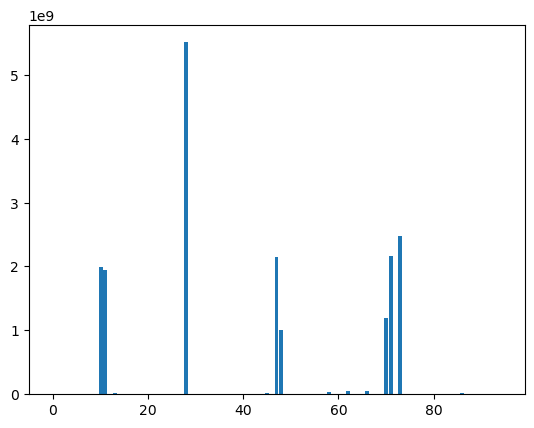

In [8]:
plt.bar(range(X.shape[1]),X.mean(axis=0))
plt.show()

Yikes! Looks like at least 9 features are on the order of 1 billion! We can use the function `StandardScaler` to transform the data to mean 0 and variance 1 in each feature.

In [9]:
Xs = StandardScaler().fit_transform(X)

Now the distribution of each feature has mean 0 and variance 1. Plot the histogram for any column to verify.

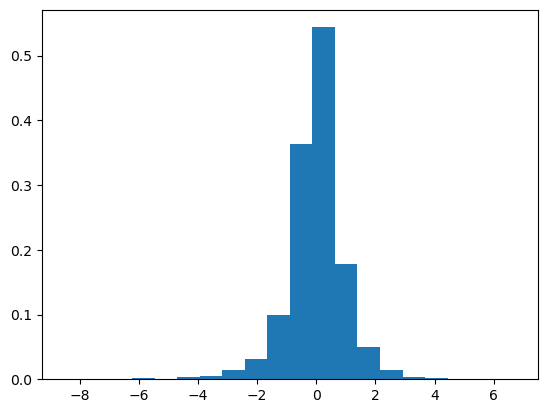

In [10]:
plt.hist(Xs[:,1],bins=20,density=True)
plt.show()

Now let's try to fit a logistic regressin model to the scaled data:

In [11]:
model = LogisticRegression(max_iter=1000).fit(Xs,y)

In [12]:
model.n_iter_

array([169], dtype=int32)

The number of iterations is far fewer after feature scaling. Let's now increase the regularization parameter $\alpha$.

In [13]:
model = LogisticRegression(C=0.01,max_iter=1000).fit(Xs,y)

In [14]:
model.n_iter_

array([30], dtype=int32)

Even fewer iterations to fit the model!

**Conclusion:** Feature scaling and regularization improve convergence of the numerical method used to fit a logistic regression model.

Check out [Wikipedia: Feature Scaling](https://en.wikipedia.org/wiki/Feature_scaling) and the [sklearn documentation](https://scikit-learn.org/stable/modules/preprocessing.html#standardization-or-mean-removal-and-variance-scaling) for more about feature scaling.

**Analyze and Assess:**

Here, we will also be following some pre-assigned tasks to help guide the analysis and assessment.

### Choosing a Regularization Parameter

Fit a logistic regression model to the scaled data for several regularization parameters from $\alpha = 10^{-1}$ to $\alpha = 10^4$ and plot the cross entropy versus $\Vert \mathbf{W} \Vert^2$. Inspect the graph and choose a value $\alpha$ where the cross entropy is low but the norm squared of the weights $\Vert \mathbf{W} \Vert^2$ is not too high. This is the value where the points in the plot start to flatten out. This is where where our model fits the data but is not *over-fitting*.

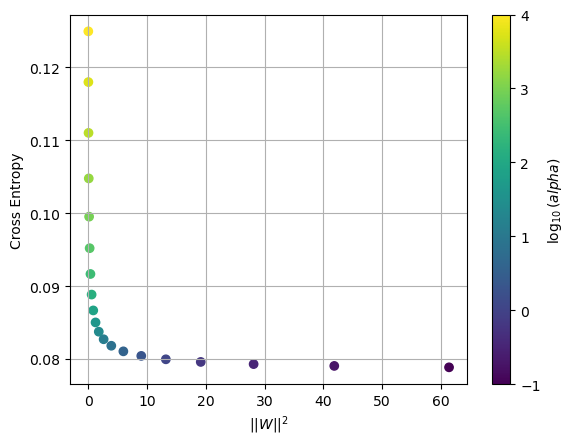

In [15]:
def costCE(W,b,X,y):
    N,p = X.shape
    W = np.array(W).reshape(p,1)
    y = np.array(y).reshape(N,1)
    S = 1/(1 + np.exp(-(X@W + b)))
    L = -1/N*np.sum(y*np.log(S) + (1 - y)*np.log(1 - S))
    return L

CEs = []
Rs = []
alphas = np.logspace(-1,4,20)
for alpha in alphas:
    model = LogisticRegression(C=1/alpha,max_iter=1000).fit(Xs,y)
    W = model.coef_
    b = model.intercept_
    CE = costCE(W,b,Xs,y)
    R = np.linalg.norm(W)**2
    CEs.append(CE)
    Rs.append(R)

plt.scatter(Rs,CEs,c=np.log10(alphas))
plt.grid(True), plt.colorbar(label='$\log_{10}(alpha)$')
plt.xlabel('$|| W ||^2$')
plt.ylabel('Cross Entropy')
plt.show()

From the plot, we are looking for a good balance between a reduction in the cross entropy error and how large $\| W \|^2$ is.  It seems that our cross entropy error levels out around the dark blue/purple dots (i.e., when $\| W \|^2 \approx 10 - 30.$  Based on the colour bar, the exponent on $10^k$ is approximately in the range $(-0.5,0.5).$  The "nicest" number to pick in this range is $k=0$, because then we would have that $10^0=1$, and $C = 1/\alpha$ in the `LogisticRegression` function is $C=1.$

Fit a logistic regression model on the scaled data using your chosen value $\alpha$. Increase the value $\alpha$ and note the number of iterations required. Does it decrease? It should.

In [16]:
model = LogisticRegression(C=1,max_iter=1000).fit(Xs,y)
model.n_iter_

array([169], dtype=int32)

### Closer Look at Model Evaluation

Now that we know we should scale the features and increase the regularization parameter $\alpha$ to improve convergence, let's build a model and test it using `train_test_split` and use `score` to compute the model accuracy.

In [17]:
Xs_train, Xs_test, y_train, y_test = train_test_split(Xs,y,test_size=0.2)

In [18]:
model = LogisticRegression(C=1,max_iter=1000).fit(Xs_train,y_train)

In [19]:
model.n_iter_

array([154], dtype=int32)

In [20]:
model.score(Xs_test,y_test)

0.9618768328445748

The score should be around 96%. That's good! But is it actually? What if our model just simply predicted $y=0$ for any input? Then the accuracy score is just the number of target values $y=0$ divided by the total number of values.

In [21]:
len(y[y == 0])/len(y)

0.967737204868749

That's 96% also! So our model is no better than just predicting the company is not bankrupt (when we use accuracy as a metric).

Instead let's use the function `confusion_matrix` to construct the [confusion matrix](https://en.wikipedia.org/wiki/Confusion_matrix).

A confusion matrix is a visualization of how well the classification is performed.  Across the row, we have the predicted true and false, and down a column we have the actual true and false.  If the classification is good, we will see all see a diagonal $2 \times 2$ matrix indicating that the machine learning model correctly classifies all true points as true and all false points as false. 

The off-diagonal elements show false positives (i.e., when the machine learning classification classifies a point as true, but the point is actually false) and false negatives (i.e., when the machine learning classigication classifies a point as false, but it is actually true). We generally do not want to see too many entries in the off-diagonal elements, however, it is up to the modeller to decide what an "acceptable" level of accuracy is for the context of the problem they are trying to model. 

We can calculate $3$ metrics from this:
- Accuracy = (TP + TN)/(P + N)
    - Measures the fraction of correctly identified cases 
- Precision = (TP)/(TP + FP)
    - This is sometimes called positive predictive value
    - Measures the fraction of positive identified cases from all predicted positive cases 
- Recall = (TP)/(TP + FN)
    - This is sometimes called the true positive rate or the sensitivity
    - Measures the fraction of positive identified cases from all actual positive cases

We can also calculate the F1-score, which is the harmonic mean of the Precision and Recall.  The calculation uses the harmonic mean because it penalizes for extreme values.  The F1-score generally gives a better measure of incorrectly classified cases and is most useful for imbalanced data. 

In [22]:
## the entries of the confusion matrix are:
## C[0,0] true negatives 
## C[1,0] false negatives  
## C[1,1] true positives
## C[0,1] false positives

## note that this is slightly different than the confusion matrix on the wikipedia page!

C = confusion_matrix(y_test,model.predict(Xs_test))

C

array([[1307,   13],
       [  39,    5]])

How many of total bankrupt companies were correctly identified?

In [23]:
## can calculate the percentage of correctly classified bankrupt companies:
C[1,1]/(C[1,0] + C[1,1])

0.11363636363636363

Well that's better than not detecting any bankruptcies at all!

Check out the [documentation](https://scikit-learn.org/stable/modules/generated/sklearn.metrics.confusion_matrix.html) for more about the confusion matrix.

Some additional thoughts to guide the analysis:
- how does the split of the training to testing change the model?  What happens when we change to a 70-30 split?
- what might happen to the model if we cannot assume that historical trends continue and/or that there are no large changes in the stock market?  Is this a reasonable assumption to make?

## Glass Data

The file `glass.csv` comes from the [UC Irvine Machine Learing Repository](https://archive.ics.uci.edu/dataset/42/glass+identification) and contains a dataset with 214 samples and 9 features describing physical properties of different types of glass. The features are:

* RI: refractive index
* Na: Sodium 
* Mg: Magnesium
* Al: Aluminum
* Si: Silicon
* K: Potassium
* Ca: Calcium
* Ba: Barium
* Fe: Iron
  
The unit of measurement for elements are weight percent in corresponding oxide. The target value is $y=1$ if the glass is used for building or vehicle windows and $y=0$ if not.

Construct a mathematical model to predict whether the glass will be used to build vehicle or building windows or not. 

**Problem Statement:**

Using the features in the `glass.csv` file, determine a Logistic Regression model for if the glass will be used to building or vehicle windows or not.

**Variables and parameters:**
- We have a target variable (dependent variable) of building or vehicle windows, which is called "windows".
- We have $9$ features (independent variables) for this dataset:
    - RI: refractive index
    - Na: Sodium
    - Mg: Magnesium
    - Al: Aluminum
    - Si: Silicon
    - K: Potassium
    - Ca: Calcium
    - Ba: Barium
    - Fe: Iron
- Regularization parameter, $\alpha$
- Vector of logistic regression parameters, $\bf{W}$
- Bias ${b}$

**Assumptions and Constraints:**
- other than the features listed in the `glass.csv` file, there are no other factors that influence whether it is used to build windows or not
- the measuring device to measure the composition and the refractive index of the glass is sufficiently accurate
- the data is appropriate for logistic regression since the target variable has binary output
- trends in historical data will continue and there is no sudden changes (e.g., process to make glass does not drastically change)

**Build Solutions:**

Here, we will follow some pre-assigned tasks for the data. 

### Import Data

In [24]:
df = pd.read_csv('glass.csv')

In [25]:
df.head()

,RI,Na,Mg,Al,Si,K,Ca,Ba,Fe,window
0,1.52101,13.64,4.49,1.10,71.78,0.06,8.75,0.0,0.0,1
1,1.51761,13.89,3.60,1.36,72.73,0.48,7.83,0.0,0.0,1
2,1.51618,13.53,3.55,1.54,72.99,0.39,7.78,0.0,0.0,1
3,1.51766,13.21,3.69,1.29,72.61,0.57,8.22,0.0,0.0,1
4,1.51742,13.27,3.62,1.24,73.08,0.55,8.07,0.0,0.0,1


In [26]:
df.shape

(214, 10)

Select the data matrix `X` and target vector `y`:

In [27]:
X = df.iloc[:,:-1].values
y = df.iloc[:,-1].values

### Model with Unscaled Data

Construct a logistic regression model using the unscaled data matrix `X`. Increase the parameter `max_iter` if necessary. How many iterations are required to fit the data with regularization parameter $C=1$?

In [28]:
model = LogisticRegression(max_iter=1000).fit(X,y)

In [29]:
model.n_iter_

array([262], dtype=int32)

Construct logistic regression models using several different regularization parameters and plot the cross entropy versus $\Vert \mathbf{W} \Vert^2$. Inspect the graph and choose a value $\alpha$ where the cross entropy is low but the norm squared of the weights $\Vert \mathbf{W} \Vert^2$ is not too high.

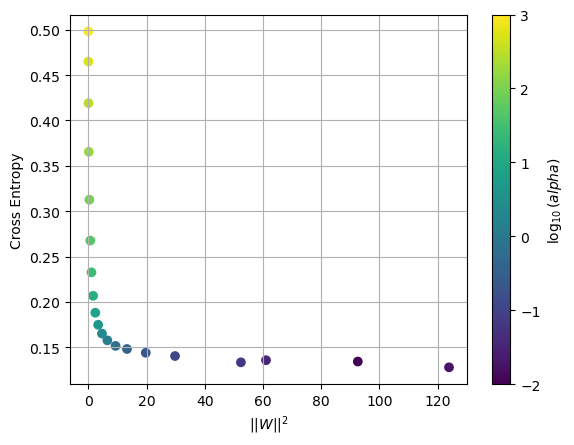

In [30]:
CEs = []
Rs = []
alphas = np.logspace(-2,3,20)
for alpha in alphas:
    model = LogisticRegression(C=1/alpha,max_iter=1000).fit(X,y)
    W = model.coef_
    b = model.intercept_
    CE = costCE(W,b,X,y)
    R = np.linalg.norm(W)**2
    CEs.append(CE)
    Rs.append(R)

plt.scatter(Rs,CEs,c=np.log10(alphas))
plt.grid(True), plt.colorbar(label='$\log_{10}(alpha)$')
plt.xlabel('$|| W ||^2$')
plt.ylabel('Cross Entropy')
plt.show()

Looks again we can choose $\alpha = 10^{-1}$, since we see a good balance of decrease in the cross entropy function and the size of $\| W \|^2$.  Note here that if we increase $\| W \|^2$ via making $\alpha$ smaller, after $\alpha = 10^{-1},$ we do not see much change in the cross entropy value. We therefore need to input $C=1/10^{-1}$ or $C = 10$ into `LogisticRegression`.

Use `train_test_split` to create training and testing sets. Use the value $\alpha$ determined in the previous step to construct a logistic regression model and use `score` to evaluate the model accuracy. Note the number of iterations required to fit the model.

In [31]:
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.3)
model = LogisticRegression(C=10,max_iter=1000).fit(X_train,y_train)
print('Iterations =',model.n_iter_[0])
model.score(X_test,y_test)

Iterations = 195


0.9846153846153847

### Model with Scaled Data

Use the class `StandardScaler` to scale the data and then repeat each step above using the scaled data.

In [32]:
Xs = StandardScaler().fit_transform(X)

In [33]:
model = LogisticRegression().fit(Xs,y)

In [34]:
model.n_iter_

array([24], dtype=int32)

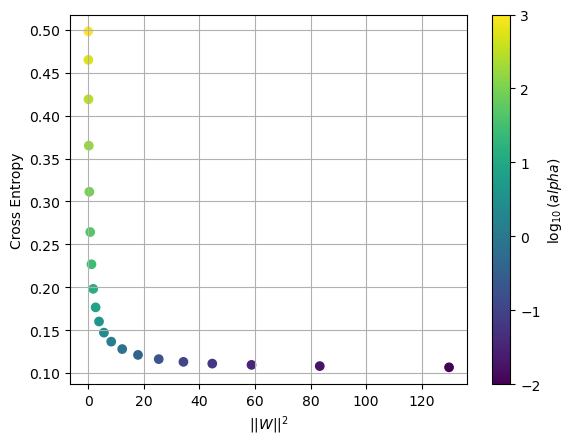

In [35]:
CEs = []
Rs = []
alphas = np.logspace(-2,3,20)
for alpha in alphas:
    model = LogisticRegression(C=1/alpha,max_iter=1000).fit(Xs,y)
    W = model.coef_
    b = model.intercept_
    CE = costCE(W,b,Xs,y)
    R = np.linalg.norm(W)**2
    CEs.append(CE)
    Rs.append(R)

plt.scatter(Rs,CEs,c=np.log10(alphas))
plt.grid(True), plt.colorbar(label='$\log_{10}(alpha)$')
plt.xlabel('$|| W ||^2$')
plt.ylabel('Cross Entropy')
plt.show()

Again, looks like we can choose $\alpha = 10^{-1}.$ 

In [36]:
Xs_train,Xs_test,y_train,y_test = train_test_split(Xs,y,test_size=0.3)
model = LogisticRegression(C=10,max_iter=1000).fit(Xs_train,y_train)
print('Iterations =',model.n_iter_[0])
model.score(Xs_test,y_test)

Iterations = 37


0.8769230769230769

### Compare Results

Some guiding thoughts for the assess and analyze phase:
- Compare the accuracy, number of iterations and cross entropy versus $\Vert \mathbf{W} \Vert^2$ graph.  
- Which model would you choose to predict a new data entry?  Why?
- How does the test-train split change the output of the model?
- How does the choice of regularization parameter $\alpha$ change the model output?
- How might this result change if we receive not very accurate measurements of the ion composition of the glass and/or the refractive index?  I.e., how might uncertainty in the measurements change our results?

The most important thing is that a model fit on scaled data converges more quickly. Neural networks are essentially millions of logistic functions composed together and so feature scaling to improve convergence is very important!